### Simple Workflow with Lang graph

In [1]:
from langgraph.graph import StateGraph

In [2]:
class State():
    text:str

workflow1=StateGraph(State)



In [3]:
def function1(state:State):
    return {"text":state["text"] + " from first function"}

def function2(state:State):
    return {"text":state["text"] + " and sanskar from second function"}

In [4]:
workflow1.add_node("function1",function1)
workflow1.add_node("function2",function2)

In [5]:
workflow1.add_edge("function1","function2")

In [6]:
workflow1.set_entry_point("function1")

In [7]:
workflow1.set_finish_point("function2")

In [8]:
app=workflow1.compile()

In [9]:
app.invoke({"text":"Hii"})

{'text': 'Hii from first function and sanskar from second function'}

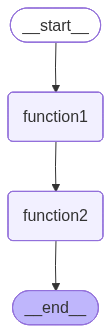

In [10]:
from IPython.display import Image,display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

### Workflow with LLM

In [16]:
from langchain_groq import ChatGroq


llm=ChatGroq(model="llama-3.1-8b-instant")

/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10511.27it/s]


In [18]:
llm.invoke("Hii").content

'How can I assist you today?'

In [19]:
def function1(state:State):
    llm=ChatGroq(model="llama-3.1-8b-instant")
    response=llm.invoke(state["text"]).content
    return {"text":response}

In [27]:
def function2(state:State):
    upper_case=state["text"].upper()
    return {"text":upper_case}

In [28]:
from langgraph.graph import StateGraph

class State():
    text:str

workflow2=StateGraph(State)

workflow2.add_node("function1",function1)
workflow2.add_node("function2",function2)

In [29]:
workflow2.add_edge("function1","function2")

In [30]:
workflow2.set_entry_point("function1")
workflow2.set_finish_point("function2")

In [31]:
app=workflow2.compile()

In [32]:
app.invoke({"text":"Hii"})

{'text': 'HELLO. HOW CAN I ASSIST YOU TODAY?'}

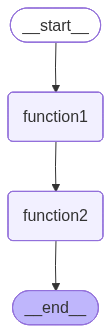

In [33]:
from IPython.display import Image,display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [34]:
app.invoke({"text":"Who is the prime minister of India"})

{'text': 'AS OF MY CUT-OFF KNOWLEDGE IN 2023, THE PRIME MINISTER OF INDIA IS NARENDRA MODI. HOWEVER, MY KNOWLEDGE IS OUTDATED, AND I MAY NOT HAVE THE MOST RECENT INFORMATION.'}

In [35]:
app.invoke({"text":"What is the temperature of today in mumbai"})

{'text': 'HOWEVER, I\'M A LARGE LANGUAGE MODEL, I DON\'T HAVE REAL-TIME ACCESS TO CURRENT WEATHER CONDITIONS. BUT I CAN SUGGEST A FEW OPTIONS TO FIND THE CURRENT TEMPERATURE IN MUMBAI:\n\n1. **GOOGLE SEARCH**: YOU CAN SIMPLY TYPE "CURRENT TEMPERATURE IN MUMBAI" AND GOOGLE WILL SHOW YOU THE CURRENT TEMPERATURE AND OTHER WEATHER CONDITIONS.\n2. **WEATHER WEBSITES**: WEBSITES LIKE ACCUWEATHER, WEATHER.COM, OR THE INDIAN METEOROLOGICAL DEPARTMENT (IMD) WEBSITE CAN PROVIDE YOU WITH THE CURRENT TEMPERATURE IN MUMBAI.\n3. **MOBILE APPS**: YOU CAN DOWNLOAD MOBILE APPS LIKE DARK SKY, WEATHER UNDERGROUND, OR THE IMD APP TO GET THE CURRENT TEMPERATURE AND OTHER WEATHER CONDITIONS IN MUMBAI.\n\nPLEASE NOTE THAT THE TEMPERATURE MAY VARY DEPENDING ON THE LOCATION WITHIN MUMBAI AND THE TIME OF DAY.\n\nIF YOU WANT, I CAN ALSO PROVIDE YOU WITH THE AVERAGE TEMPERATURE IN MUMBAI FOR DIFFERENT SEASONS.'}

In [37]:
print(app.invoke({"text":"Make me a ecommerce website"}))

{'text': 'I CAN PROVIDE A BASIC STRUCTURE AND CODE FOR AN E-COMMERCE WEBSITE USING HTML, CSS, AND JAVASCRIPT. FOR THIS EXAMPLE, WE WILL BE USING A SIMPLE SHOPPING CART SYSTEM AND A MOCK DATABASE FOR PRODUCTS.\n\n**NOTE:** THIS IS A SIMPLIFIED EXAMPLE AND A REAL-WORLD E-COMMERCE WEBSITE WOULD REQUIRE A MORE COMPLEX SETUP, INCLUDING A DATABASE, PAYMENT GATEWAY INTEGRATION, AND SECURITY MEASURES.\n\n**DIRECTORY STRUCTURE:**\n\n```BASH\nECOMMERCE-WEBSITE/\nINDEX.HTML\nSTYLES/\nSTYLES.CSS\nSCRIPT/\nSCRIPT.JS\nIMAGES/\nPRODUCT1.JPG\nPRODUCT2.JPG\n...\nVENDOR/\nJQUERY.MIN.JS\nBOOTSTRAP.MIN.CSS\n...\nDB.JSON\n```\n\n**INDEX.HTML:**\n\n```HTML\n<!DOCTYPE HTML>\n<HTML LANG="EN">\n<HEAD>\n    <META CHARSET="UTF-8">\n    <META NAME="VIEWPORT" CONTENT="WIDTH=DEVICE-WIDTH, INITIAL-SCALE=1.0">\n    <TITLE>ECOMMERCE WEBSITE</TITLE>\n    <LINK REL="STYLESHEET" HREF="STYLES/STYLES.CSS">\n    <LINK REL="STYLESHEET" HREF="VENDOR/BOOTSTRAP.MIN.CSS">\n</HEAD>\n<BODY>\n    <NAV CLASS="NAVBAR NAVBAR-EXPAND-LG